Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Taller de análisis de datos**

Resolver las siguientes consignas.

### **Consigna 01**

> En un *data frame* llamado `vuelos`, cargar los datos que se encuentran en el archivo `td6-p02-c-datos-vuelos.txt`, disponible en el Campus Virtual, y observarlos.

In [1]:
import pandas as pd

vuelos = pd.read_table('td6-p02-c-datos-vuelos.txt', delimiter = ';')

In [2]:
vuelos.head()
vuelos["UniqueCarrier"].unique()

<StringArray>
['WN', 'OO', 'US', 'MQ', 'AA']
Length: 5, dtype: str

In [3]:
vuelos.tail()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
3318075,2008,12,31,3,2005.0,2005,2243.0,2300,AA,2491,...,7.0,15.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3318076,2008,12,21,7,1813.0,1645,2248.0,1950,AA,2500,...,30.0,95.0,0,NaN,0,88.0,0.0,90.0,0.0,0.0
3318077,2008,12,28,7,1640.0,1645,1935.0,1950,AA,2500,...,20.0,19.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3318078,2008,12,25,4,1627.0,1600,1947.0,1925,AA,2501,...,5.0,42.0,0,NaN,0,22.0,0.0,0.0,0.0,0.0
3318079,2008,12,19,5,1558.0,1400,2101.0,1655,AA,2548,...,27.0,107.0,0,NaN,0,0.0,0.0,246.0,0.0,0.0


### **Consigna 02**

> ¿Datos de cuántos vuelos tiene el data frame `vuelos`?

In [4]:
vuelos.shape[0] # Tener en cuenta que vuelos.shape devuelve: (n filas, n columnas).

3318080

In [5]:
len(vuelos.index) # Alternativa, por si no nos acordamos si antes tiene que ser o shape[0] o shape[1].

3318080

**Respuesta**: el data frame `vuelos` tiene datos de 3.318.080 vuelos.

### **Consigna 03**

> ¿Cuántas columnas tiene el data frame `vuelos`?

In [6]:
vuelos.shape[1]

28

In [7]:
len(vuelos.columns) # Alternativa, por si no nos acordamos si antes tiene que ser o shape[0] o shape[1].

28

**Respuesta**: el data frame `vuelos` tiene 28 columnas.

In [8]:
vuelos['demorado'] = vuelos['ArrDelay'] > 20

vuelos[['ArrDelay', 'demorado']]

,ArrDelay,demorado
0,-14.0,False
1,2.0,False
2,14.0,False
3,-6.0,False
4,34.0,True
...,...,...
3318075,-17.0,False
3318076,178.0,True
3318077,-15.0,False
3318078,22.0,True


### **Consigna 04**

> Considerar un vuelo como demorado si el valor de `ArrDelay` es superior a 20 min. Teniendo esto en cuenta,
>
> * ¿qué aerolínea (*tip*: aprovechar el diccionario de variables e Internet) tiene la mayor proporción de vuelos demorados?
>
> * Y, ¿en qué aeropuerto de destino es más común (en términos relativos) que haya demoras en el arribo?
>
> *Tip*: qué significa cada código lo pueden encontrar en la siguiente página: https://www.iata.org/en/publications/directories/code-search/.

In [9]:
vuelos_demorados = vuelos[vuelos["ArrDelay"]> 20]
vuelos_demorados["UniqueCarrier"].value_counts()/vuelos["UniqueCarrier"].value_counts()

UniqueCarrier
AA    0.220650
MQ    0.191959
OO    0.149205
US    0.141364
WN    0.144385
Name: count, dtype: float64

AA: American Airlines.

**Respuesta**: la aerolínea que tiene la mayor proporción de vuelos demorados es American Airlines (AA).

In [10]:
dest_demorados = vuelos_demorados["Dest"].value_counts()/vuelos["Dest"].value_counts()
dest_demorados.sort_values(ascending= False)


Dest
OTH    0.365571
EGE    0.356979
GUC    0.333333
MQT    0.326284
EWR    0.310471
         ...   
WYS    0.060606
BLI    0.057851
IYK    0.040881
CYS         NaN
OGD         NaN
Name: count, Length: 230, dtype: float64

OTH: Southwest Oregon Rgnl (North Bend).

**Respuesta**: el aeropuerto de destino en que es más común (en términos relativos) que haya demoras en el arribo es Southwest Oregon Rgnl (OTH).

### **Consigna 05**

> ¿Es más o menos común que haya vuelos demorados los fines de semana respecto a los días de semana?

In [11]:
vuelos['fin_de_semana'] = (vuelos['DayOfWeek'] == 6) | (vuelos['DayOfWeek'] == 7)

vuelos[['DayOfWeek', 'fin_de_semana']]

,DayOfWeek,fin_de_semana
0,4,False
1,4,False
2,4,False
3,4,False
4,4,False
...,...,...
3318075,3,False
3318076,7,True
3318077,7,True
3318078,4,False


In [12]:
cant_vuelos_dias = vuelos[vuelos['fin_de_semana']== False]
cant_vuelos_dias

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,demorado,fin_de_semana
0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
2,2008,1,3,4,628.0,620,804.0,750,WN,448,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
3,2008,1,3,4,926.0,930,1054.0,1100,WN,1746,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,...,0,NaN,0,2.0,0.0,0.0,0.0,32.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318073,2008,12,29,1,2005.0,2005,2237.0,2300,AA,2491,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
3318074,2008,12,30,2,2032.0,2005,2317.0,2300,AA,2491,...,0,NaN,0,0.0,17.0,0.0,0.0,0.0,False,False
3318075,2008,12,31,3,2005.0,2005,2243.0,2300,AA,2491,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False
3318078,2008,12,25,4,1627.0,1600,1947.0,1925,AA,2501,...,0,NaN,0,22.0,0.0,0.0,0.0,0.0,True,False


In [13]:
cant_vuelos_dias = vuelos.groupby('fin_de_semana')['fin_de_semana'].describe()[['count']].rename(columns = {'count': 'cant_vuelos'})
cant_demorados_dias = vuelos.groupby('fin_de_semana')[['demorado']].sum().rename(columns = {'demorado': 'cant_demorados'})

cant_dias = pd.merge(cant_vuelos_dias, cant_demorados_dias, on = 'fin_de_semana')

cant_dias['prop_demorados'] = cant_dias['cant_demorados'] / cant_dias['cant_vuelos']

cant_dias[['prop_demorados']].sort_values(by = 'prop_demorados', ascending = False)

,prop_demorados
fin_de_semana,
False,0.1678
True,0.159824


**Respuesta**: es menos común que haya vuelos demorados los fines de semana respecto a los días de semana (ya que 0,159824 < 0,1678).

### **Consigna 06**

> Para los casos en que hay minutos de demora debido al clima, ¿cuál es la duración promedio de esas demoras? *Tip*: piensen si, para resolver esta consigna, tiene o no sentido considerar los ceros.

No tiene sentido considerar los ceros, porque se pide realizar el cálculo para los casos en que *hay* minutos de demora (debido al clima) y los ceros indican que *no hay* minutos de demora.

In [14]:
vuelos[vuelos['WeatherDelay'] > 0][['WeatherDelay']].mean()

WeatherDelay    41.220588
dtype: float64

**Respuesta**: la duración promedio de esas demoras es de, aproximadamente, 41 min.

### **Consigna 07**

> * ¿Cuáles son el número de vuelo, el origen y el destino correspondientes al vuelo más largo, en términos de tiempo, que se registra en los datos?
>
> * ¿Cuál es la duración, en horas, de dicho vuelo?

In [15]:
vuelos[vuelos['ActualElapsedTime'] == max(vuelos['ActualElapsedTime'])][['FlightNum', 'Origin', 'Dest']]

,FlightNum,Origin,Dest
787074,5,DFW,HNL


DFW: Metropolitan Area.\
HNL: Daniel K. Inouye Intl (Honolulu).

**Respuesta**: el número de vuelo, el origen y el destino correspondientes al vuelo más largo, en términos de tiempo, que se registra en los datos son 5, Metropolitan Area (DFW) y Daniel K. Inouye Intl (HNL), respectivamente.

In [16]:
vuelos[vuelos['ActualElapsedTime'] == max(vuelos['ActualElapsedTime'])][['ActualElapsedTime']] / 60

,ActualElapsedTime
787074,12.116667


**Respuesta**: la duración, en horas, de dicho vuelo es, aproximadamente, igual a 12.

### **Consigna 08**

> ¿Cuál es la cantidad de vuelos que se realiza para cada combinación origen-destino? *Tip*: guardar esta información porque es necesaria para resolver la siguiente consigna.

In [17]:
cant_vuelos_origen_destino = pd.crosstab(vuelos['Origin'], vuelos['Dest'])

cant_vuelos_origen_destino

Dest,ABE,ABI,ABQ,ACT,ACV,AEX,ALB,AMA,ANC,ASE,...,TVC,TWF,TXK,TYR,TYS,VPS,WYS,XNA,YKM,YUM
Origin,,,,,,,,,,,,,,,,,,,,,
ABE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABI,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABQ,0,0,0,0,0,0,0,367,0,0,...,0,0,0,0,0,0,0,0,0,0
ACT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ACV,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VPS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WYS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
XNA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Respuesta**: la cantidad de vuelos que se realiza para cada combinación origen-destino se encuentra disponible en `cant_vuelos_origen_destino`, antes impresa.

### **Consigna 09**

> ¿Cuál es el tramo origen-destino para el que se hicieron más vuelos? *Tip*: guardar también esta información porque es necesaria para resolver la siguiente consigna.

In [18]:
cant_vuelos_origen_destino.max(axis = 1)

Origin
ABE     742
ABI    2660
ABQ    5141
ACT    1993
ACV    2343
       ... 
VPS    1968
WYS     264
XNA    3114
YKM     340
YUM    1044
Length: 228, dtype: int64

In [19]:
cant_vuelos_origen_destino.max(axis = 1).max()

np.int64(11256)

In [20]:
cant_vuelos_origen_destino.max(axis = 1).idxmax() # Origen: axis = 1 (fila).

'LAX'

In [21]:
cant_vuelos_origen_destino.max(axis = 0).idxmax() # Destino: axis = 0 (columna).

'SAN'

LAX: Los Angeles Intl.\
SAN: San Diego Intl.

**Respuesta**: el tramo origen-destino para el que se hicieron más vuelos es LAX-SAN; es decir, desde Los Angeles Intl. hacia San Diego Intl.

No nos olvidemos de guardar esta información.

In [22]:
tramo_mas_vuelos_origen = cant_vuelos_origen_destino.max(axis = 1).idxmax()
tramo_mas_vuelos_destino = cant_vuelos_origen_destino.max(axis = 0).idxmax()

### **Consigna 10**

> * Considerando los vuelos correspondientes al tramo más frecuente y que no fueron cancelados, realizar un diagrama de cajas que permita ver la distribución de la duración de los vuelos.
>
> * Una vez hecho el diagrama, ¿a qué consideran que pueden deberse los valores extremos que se visualizan en él?

In [23]:
diagrama_cajas_datos = vuelos.loc[(vuelos['Origin'] == tramo_mas_vuelos_origen) & \
    (vuelos['Dest'] == tramo_mas_vuelos_destino) & \
        (vuelos['Cancelled'] == 0)]

diagrama_cajas_datos[['Origin', 'Dest', 'Cancelled']]

,Origin,Dest,Cancelled
94570,LAX,SAN,0
94572,LAX,SAN,0
94574,LAX,SAN,0
94576,LAX,SAN,0
94578,LAX,SAN,0
...,...,...,...
3237468,LAX,SAN,0
3237469,LAX,SAN,0
3237470,LAX,SAN,0
3237471,LAX,SAN,0


**Usando Pandas**

<Axes: >

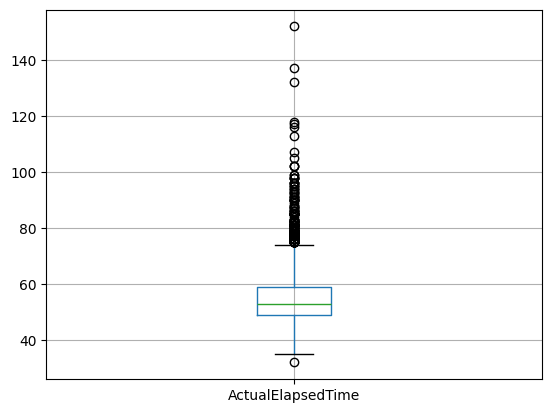

In [24]:
diagrama_cajas_datos.boxplot(column = 'ActualElapsedTime')

**Usando Matplotlib**

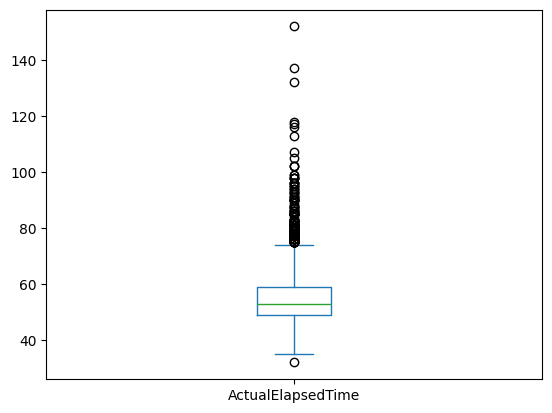

In [25]:
import matplotlib.pyplot as plt

diagrama_cajas_datos[['ActualElapsedTime']].plot(kind = 'box')
plt.show()

**Usando seaborn**

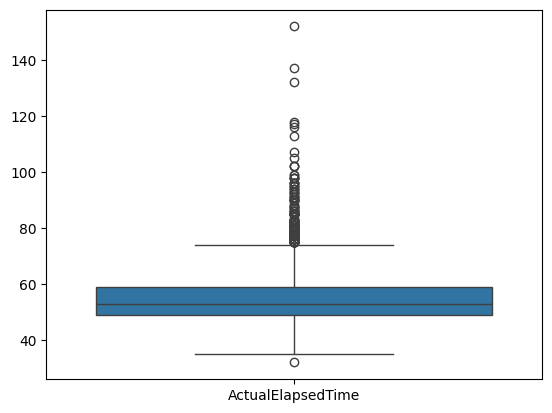

In [26]:
import seaborn as sns

plt.ioff() # Para desactivar la actualización de los gráficos.
sns.boxplot(diagrama_cajas_datos[['ActualElapsedTime']])
plt.show()

**Usando Plotly**

In [27]:
import plotly.express as px

px.box(diagrama_cajas_datos[['ActualElapsedTime']])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'variable=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa'},
              'name': '',
              'notched': False,
              'offsetgroup': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'box',
              'x': array(['ActualElapsedTime', 'ActualElapsedTime', 'ActualElapsedTime', ...,
                          'ActualElapsedTime', 'ActualElapsedTime', 'ActualElapsedTime'],
                         shape=(11128,), dtype=object),
              'x0': ' ',
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAACASEAAAAAAAIBHQAAAAAAAAE' ... 'AAAIBIQAAAAAAAAEdAAAAAAACAS0A='),
                    'dtype': 'f8'},
              'y0': ' ',
              'yaxis': 'y'}],
    'layout': {'boxmode': 'group',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'variable'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}}}
})

**Respuesta**: consideramos que los valores extremos que se visualizan en el extremo superior del diagrama pueden deberse a vuelos con demoras; mientras que aquellos que se visualizan en el extremo inferior pueden deberse a vuelos que gozaron de condiciones favorables (como viento en cola), que posibilitaron que tarden considerablemente menos que el resto en realizar el mismo trayecto (desde LAX a SAN).

### **Consigna 11**

> Hacer una figura que permita ver si la distribución de la duración de los vuelos considerados en la consigna anterior varía o no en función de si ocurre un día o de semana o de fin de semana y comentarla.

**Usando Pandas**

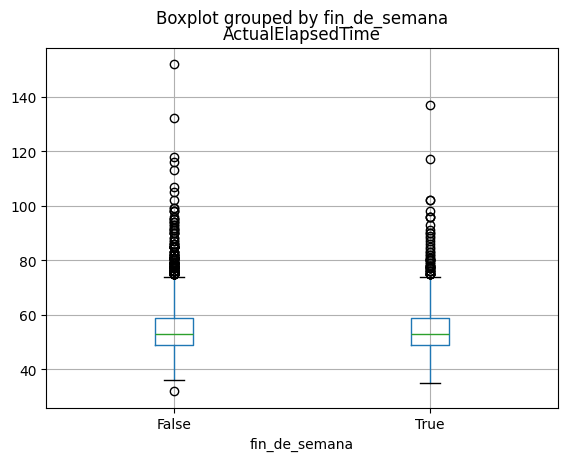

In [28]:
plt.ioff()
diagrama_cajas_datos.boxplot(column = 'ActualElapsedTime', by = 'fin_de_semana')
plt.show()

**Usando matplotlib**

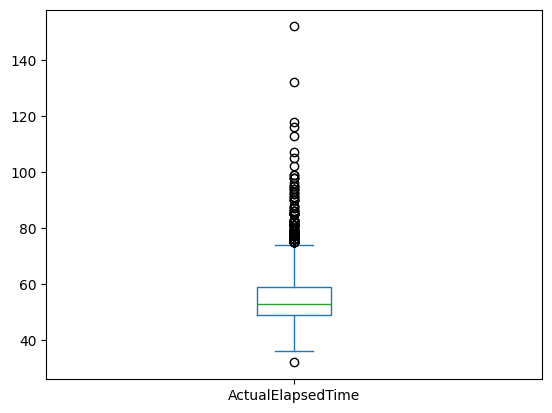

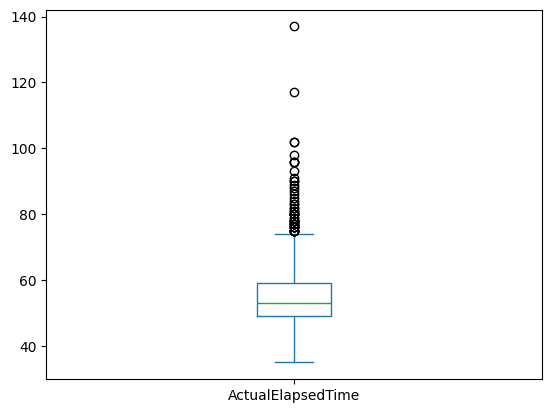

In [29]:
plt.ioff()
diagrama_cajas_datos.groupby('fin_de_semana')[['ActualElapsedTime']].plot(kind = 'box')
plt.show()

**Usando seaborn**

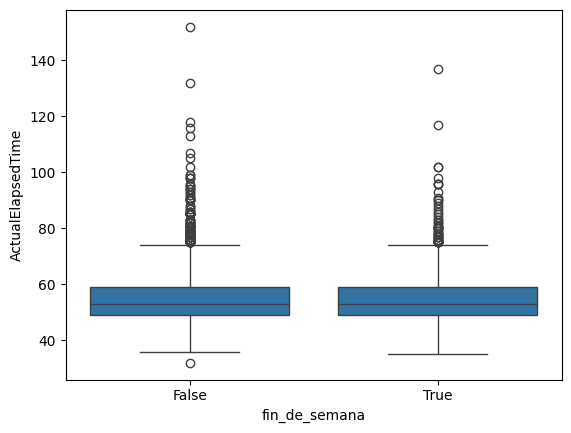

In [30]:
plt.ioff()
sns.boxplot(x = 'fin_de_semana', y = 'ActualElapsedTime', data = diagrama_cajas_datos)
plt.show()

**Usando Plotly**

In [31]:
px.box(diagrama_cajas_datos, x = 'fin_de_semana', y = 'ActualElapsedTime')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'fin_de_semana=%{x}<br>ActualElapsedTime=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa'},
              'name': '',
              'notched': False,
              'offsetgroup': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'box',
              'x': array([False, False, False, ..., True, False, False],
                         shape=(11128,), dtype=object),
              'x0': ' ',
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAACASEAAAAAAAIBHQAAAAAAAAE' ... 'AAAIBIQAAAAAAAAEdAAAAAAACAS0A='),
                    'dtype': 'f8'},
              'y0': ' ',
              'yaxis': 'y'}],
    'layout': {'boxmode': 'group',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'fin_de_semana'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'ActualElapsedTime'}}}
})

**Respuesta**: al observar los diagramas de cajas, vemos que las dos distribuciones en cuestión son extremadamente similares y, pues, esto es evidencia a favor de que la distribución de la duración de los vuelos considerados en la consigna anterior no varía en función de si ocurre un día o de semana o de fin de semana.

### **Consigna 12**

> Hacer una figura que permita ver, por mes, cuántos vuelos tienen demora en la salida y cuántos, en el arribo y comentarla.

In [32]:
demoras_salida_datos = vuelos[vuelos['DepDelay'] > 0].groupby('Month')[['Month']].count().rename(columns = {'Month': 'cant_demoras_salida'})
demoras_arribos_datos = vuelos[vuelos['ArrDelay'] > 0].groupby('Month')[['Month']].count().rename(columns = {'Month': 'cant_demoras_arribo'})

demoras_datos = pd.merge(demoras_salida_datos, demoras_arribos_datos, on = 'Month')

demoras_datos

,cant_demoras_salida,cant_demoras_arribo
Month,,
1,129544,131300
2,128489,128956
3,136800,135577
4,111417,115748
5,116892,119617
6,135523,134975
7,121130,113667
8,112794,105670
9,78588,79435


**Usando Pandas**

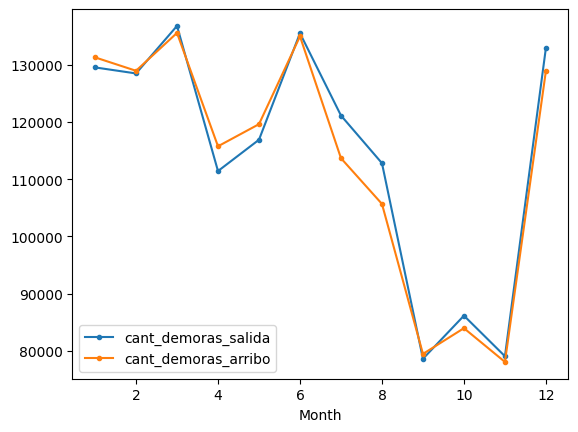

In [33]:
plt.ioff()
demoras_datos.plot(style = '.-')
plt.show()

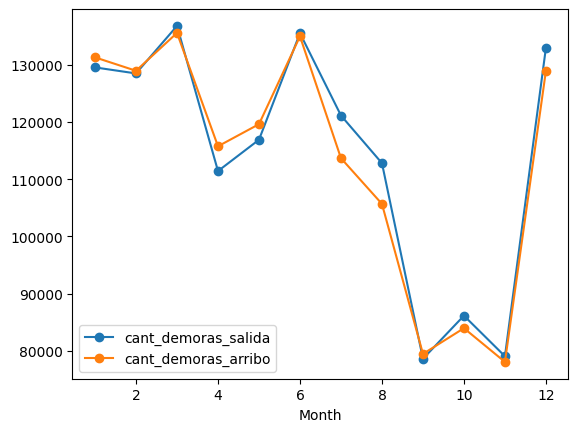

In [34]:
plt.ioff()
demoras_datos.plot(ls = '-', marker = 'o') # Alternativa.
plt.show()

**Usando matplotlib**

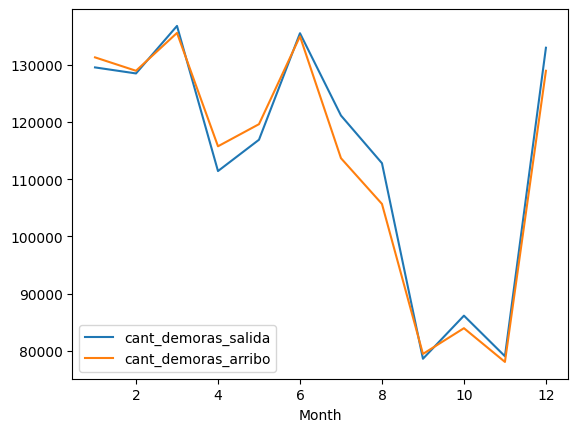

In [35]:
plt.ioff()
demoras_datos.plot(kind = 'line')
plt.show()

**Usando seaborn**

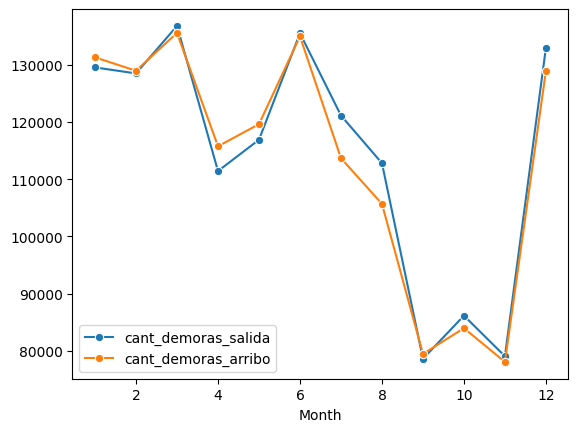

In [36]:
plt.ioff()
sns.lineplot(demoras_datos, dashes = False, markers = ['o', 'o'])
plt.show()

**Usando Plotly**

In [37]:
px.line(demoras_datos, markers = True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'variable=cant_demoras_salida<br>Month=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'cant_demoras_salida',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines+markers',
              'name': 'cant_demoras_salida',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'x': {'bdata': 'AQIDBAUGBwgJCgsM', 'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': 'CPoBAOn1AQBgFgIAObMBAJzIAQBjEQIAKtkBAJq4AQD8MgEAbVABALU0AQB5BwIA', 'dtype': 'i4'},
              'yaxis': 'y'},
             {'hovertemplate': 'variable=cant_demoras_arribo<br>Month=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'cant_demoras_arribo',
              'line': {'color': '#EF553B', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines+markers',
              'name': 'cant_demoras_arribo',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'x': {'bdata': 'AQIDBAUGBwgJCgsM', 'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': '5AACALz3AQCZEQIAJMQBAEHTAQA/DwIAA7wBAMacAQBLNgEA4EcBANQwAQC79wEA', 'dtype': 'i4'},
              'yaxis': 'y'}],
    'layout': {'legend': {'title': {'text': 'variable'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Month'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}}}
})

**Respuesta**: al observar las líneas graficadas, vemos que la cantidad de vuelos con demora en la salida y la cantidad de vuelos con demora en el arribo son muy similares entre sí a lo largo de todo el año; es en abril, mayo, julio y agosto cuando más difieren (al haber un mayor espacio entre las respectivas líneas). A su vez, la cantidad de vuelos con demora, tanto en la salida como en el arribo, tiene picos en marzo, junio y diciembre; mientras que experimenta sus valores más bajos en septiembre y noviembre.

**Aclaración**: acá se mostraron las figuras con el formato por defecto, para ver cuál es el punto de partida de cada librería. Pero, las figuras pueden ser adaptadas al formato que uno desee. De hecho, una buena figura, generalmente, requiere realizar modificaciones al formato, desde los títulos de los ejes a los colores empleados, entre otros; tal como hicimos en `td6-p01-f-matplotlib.ipynb`, `td6-p01-g-seaborn.ipynb` y `td6-p01-h-plotly.ipynb`. En los recursos adicionales compartidos, hay aún más información sobre cuáles son las modificaciones posibles y cómo se puede implementar cada una de ellas.